In [5]:
import pickle
import networkx as nx
import matplotlib.pyplot as plt

# You must import BenchmarkCase so pickle knows how to reconstruct the objects
from create_benchmark import BenchmarkCase 
from tribal import BaseTree
from tribal.multi_expansion import ConstructGraphMulti # Ensure this matches your local file

In [6]:
def view_benchmark_tree(data_file, case_index=0):
    print(f"Loading benchmark data from {data_file}...")
    with open(data_file, "rb") as f:
        dataset = pickle.load(f)
        
    if case_index >= len(dataset):
        print(f"Error: Only {len(dataset)} cases in the file.")
        return
        
    # Select the specific case you want to view
    case = dataset[case_index]
    print(f"Viewing Case [{case_index}]: {case.id}")
    print(f"Leaves: {case.n_leaves}, States: {case.n_states}")
    
    # 1. Create custom labels so we can see the states on the nodes
    labels = {}
    for node in case.tree.nodes():
        if node in case.states:
            # Format the state dictionary nicely (e.g., "char_0:1, char_1:2")
            state_vals = [f"{char.split('_')[1]}:{val}" for char, val in case.states[node].items()]
            state_str = "\n".join(state_vals)
            labels[node] = f"Node {node}\n{state_str}"
        else:
            labels[node] = f"Node {node}"
            
    # 2. Setup the plot
    plt.figure(figsize=(12, 8))
    
    # 3. Try to use Graphviz for a clean top-down tree layout. 
    # If not installed, fallback to the standard spring layout.
    try:
        from networkx.drawing.nx_agraph import graphviz_layout
        pos = graphviz_layout(case.tree, prog="dot")
    except ImportError:
        print("Graphviz not found. Falling back to spring layout.")
        pos = nx.spring_layout(case.tree, seed=42)
        
    # 4. Draw the tree
    nx.draw(
        case.tree, 
        pos, 
        with_labels=True, 
        labels=labels, 
        node_color='lightblue', 
        node_size=2500, 
        font_size=9,
        font_weight='bold',
        arrows=True,
        arrowsize=15
    )
    
    plt.title(f"Contracted Tree: {case.id}", fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

Loading benchmark data from data/benchmark_multi_data_1.pkl...
Viewing Case [43]: L5_S4_irreversible_tree_TriTrue_i3
Leaves: 5, States: 4


/var/folders/tj/bppvsjh16m990_1bbwvc05r80000gn/T/ipykernel_12083/3259095109.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


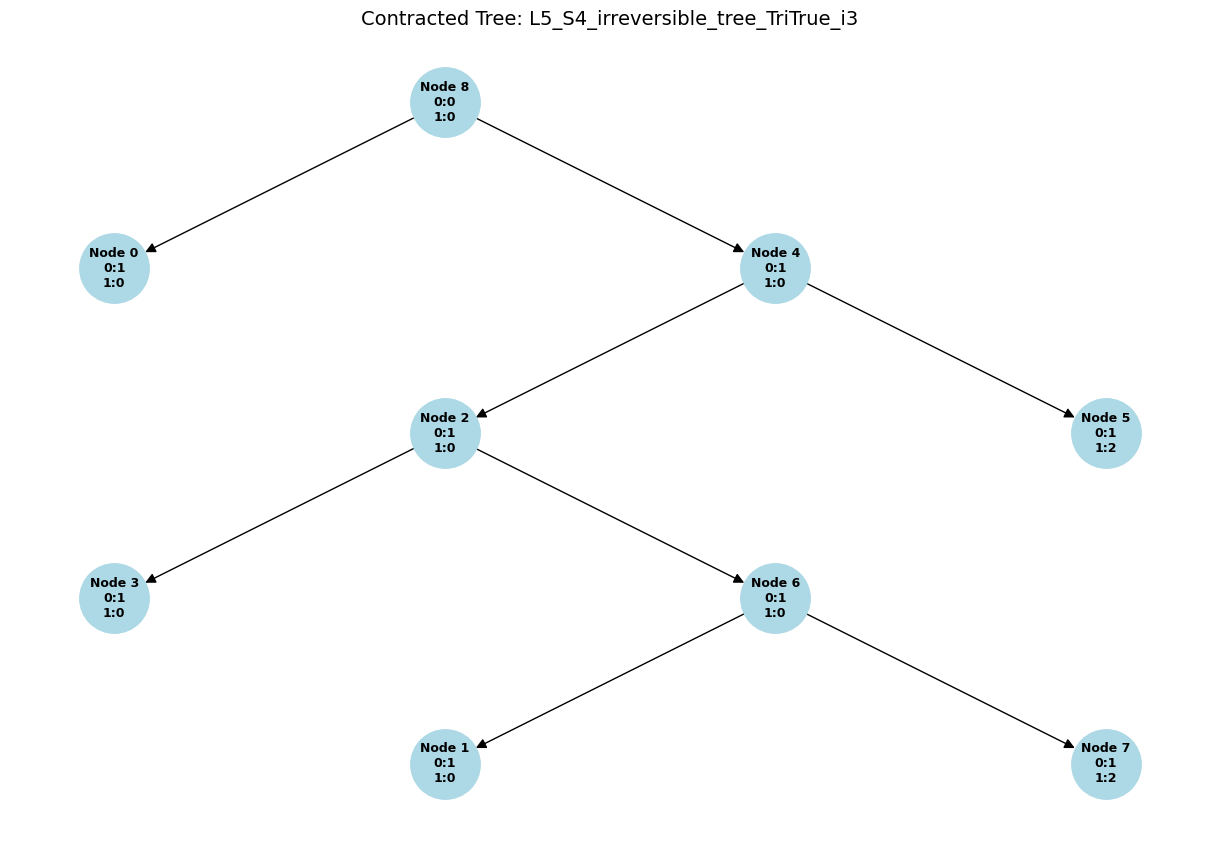

In [7]:
FILE_PATH = "data/benchmark_multi_data_1.pkl"
case=43

view_benchmark_tree(FILE_PATH, case_index=case)

In [12]:
def view_expansion_graph(data_file, case_index=0):
    print(f"Loading benchmark data from {data_file}...")
    with open(data_file, "rb") as f:
        dataset = pickle.load(f)
        
    if case_index >= len(dataset):
        print(f"Error: Only {len(dataset)} cases in the file.")
        return
        
    case = dataset[case_index]
    print(f"Viewing Expansion Graph for Case [{case_index}]: {case.id}")
    
    # 1. Rebuild the BaseTree and Expansion Graph dynamically
    base_tree = BaseTree(case.tree, root=case.root, id=0, name=case.id)
    cg = ConstructGraphMulti(case.states, case.characters, root_identifier=case.root)
    fg = cg.build(base_tree)
    
    G = fg.G
    
    # 2. Setup the plot
    plt.figure(figsize=(16, 10))
    
    # 3. Layout: Graphviz 'dot' is highly recommended for DAGs like the expansion graph
    try:
        from networkx.drawing.nx_agraph import graphviz_layout
        pos = graphviz_layout(G, prog="dot")
    except ImportError:
        print("Graphviz not found. Falling back to spring layout.")
        pos = nx.spring_layout(G, seed=42)
        
    # 4. Color formatting: Highlight the terminal nodes (leaves) in green
    terminals = fg.find_terminals()
    node_colors = ['lightgreen' if n in terminals else 'lightblue' for n in G.nodes()]
    
    # 5. Draw the graph nodes and edges
    nx.draw(
        G, 
        pos, 
        with_labels=True, 
        node_color=node_colors, 
        node_size=2000, 
        font_size=8,
        font_weight='bold',
        arrows=True,
        arrowsize=15
    )
    
    # 6. Draw the edge weights (cost = -log(P)). 
    # We filter out 0.0 costs to keep the graph from getting too cluttered.
    edge_labels = {
        (u, v): f"{d.get('weight', 0.0):.2f}"
        for u, v, d in G.edges(data=True) if d.get('weight', 0.0) > 0
    }
    print(edge_labels)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, font_color='red')
    
    plt.title(f"Expansion Graph: {case.id}\n(Green = Terminals, Red = Transition Costs)", fontsize=16)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

Loading benchmark data from data/benchmark_multi_data_1.pkl...
Viewing Expansion Graph for Case [43]: L5_S4_irreversible_tree_TriTrue_i3
{('2_(1, 0)', '2_(1, 2)'): '1.30', ('2_(1, 0)', '6_(1, 2)'): '1.30', ('4_(1, 0)', '4_(1, 2)'): '1.30', ('4_(1, 0)', '2_(1, 2)'): '1.30', ('4_(1, 0)', '5_(1, 2)'): '1.30', ('8_(0, 2)', '8_(1, 2)'): '0.71', ('8_(0, 2)', '4_(1, 2)'): '0.71', ('2_(0, 0)', '2_(1, 0)'): '0.71', ('2_(0, 0)', '2_(0, 2)'): '1.30', ('2_(0, 0)', '3_(1, 0)'): '0.71', ('2_(0, 0)', '6_(1, 0)'): '0.71', ('2_(0, 0)', '6_(0, 2)'): '1.30', ('6_(1, 0)', '6_(1, 2)'): '1.30', ('6_(1, 0)', '7_(1, 2)'): '1.30', ('8_(0, 0)', '8_(1, 0)'): '0.71', ('8_(0, 0)', '8_(0, 2)'): '1.30', ('8_(0, 0)', '0_(1, 0)'): '0.71', ('8_(0, 0)', '4_(1, 0)'): '0.71', ('8_(0, 0)', '4_(0, 2)'): '1.30', ('2_(0, 2)', '2_(1, 2)'): '0.71', ('2_(0, 2)', '6_(1, 2)'): '0.71', ('6_(0, 0)', '6_(1, 0)'): '0.71', ('6_(0, 0)', '6_(0, 2)'): '1.30', ('6_(0, 0)', '1_(1, 0)'): '0.71', ('8_(1, 0)', '8_(1, 2)'): '1.30', ('8_(1, 0)',

/var/folders/tj/bppvsjh16m990_1bbwvc05r80000gn/T/ipykernel_12083/2830622329.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


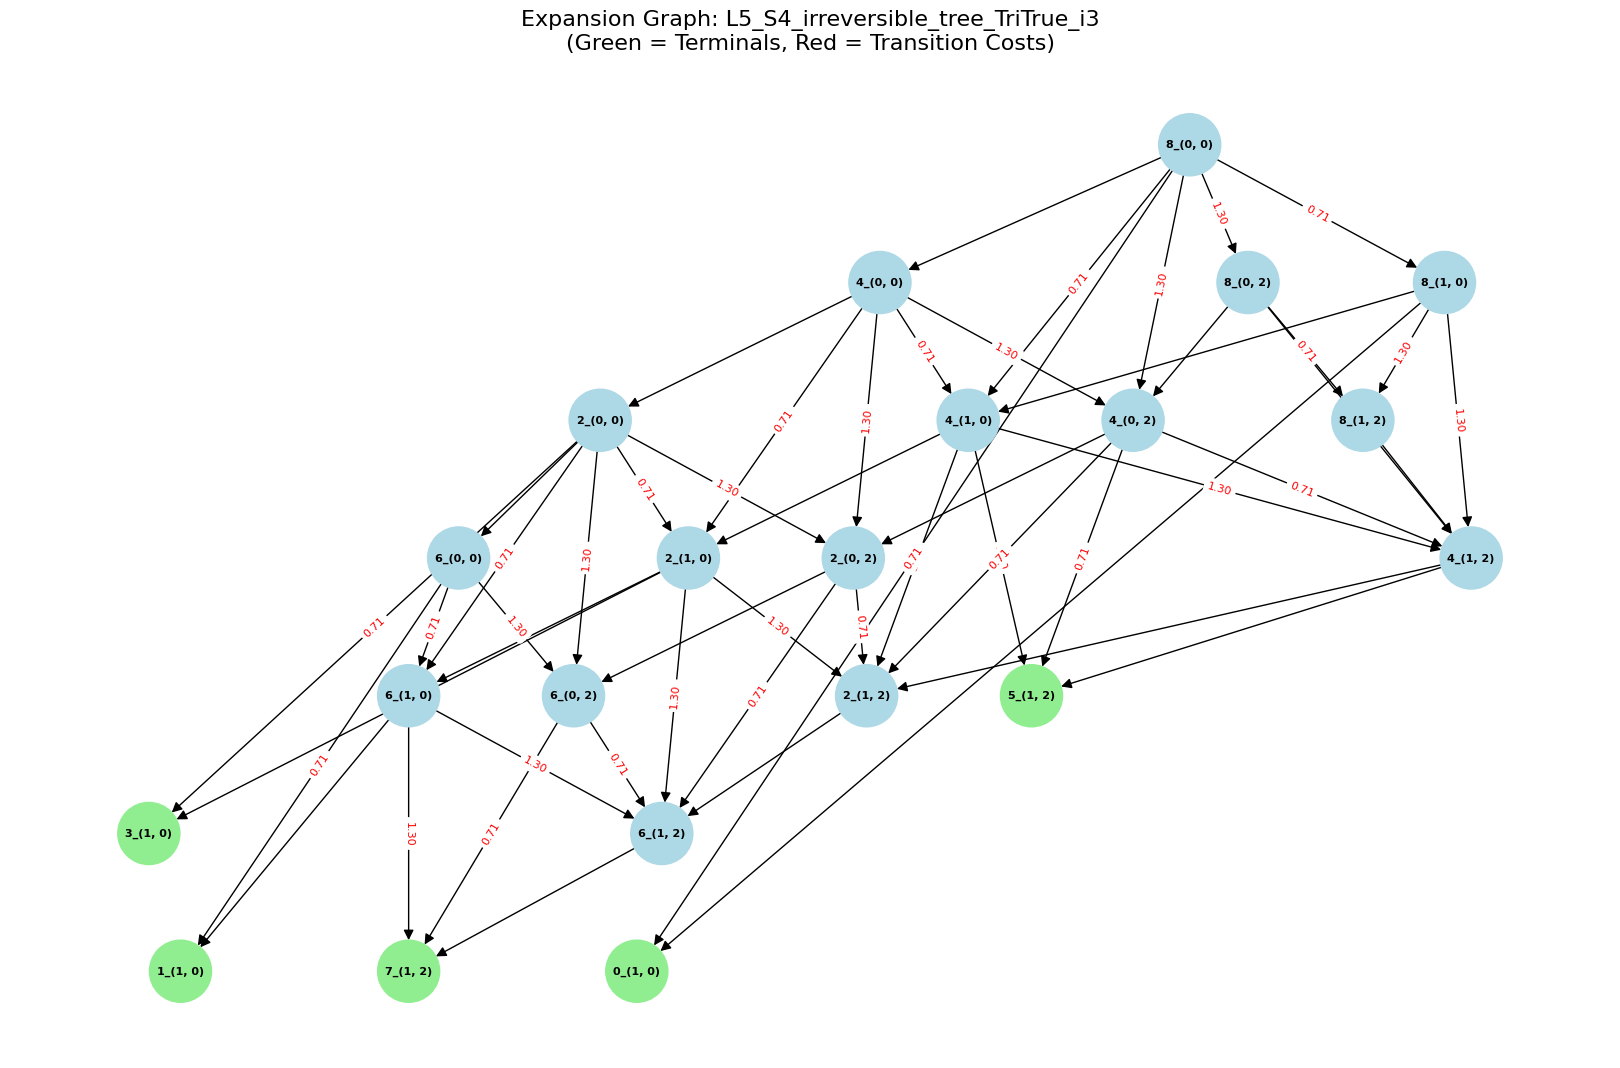

In [13]:
view_expansion_graph(FILE_PATH, case_index=case)   